In [ ]:
import sys
sys.path.append("../data") 
from archi_dict import archi_sorghum as archi

from plot_outputs import *

from openalea.archicrop.stics_io import stics_output
from openalea.archicrop.simulation import compute_1_growing_plant
from openalea.archicrop.viability import compute_viable_parameter_space

Time for 1 simulation of 74 days: 1.3733668327331543
Time for 1 simulation of 78 days: 1.5380544662475586
Time for 1 simulation of 72 days: 1.2663662433624268
Time for 1 simulation of 80 days: 1.6480154991149902


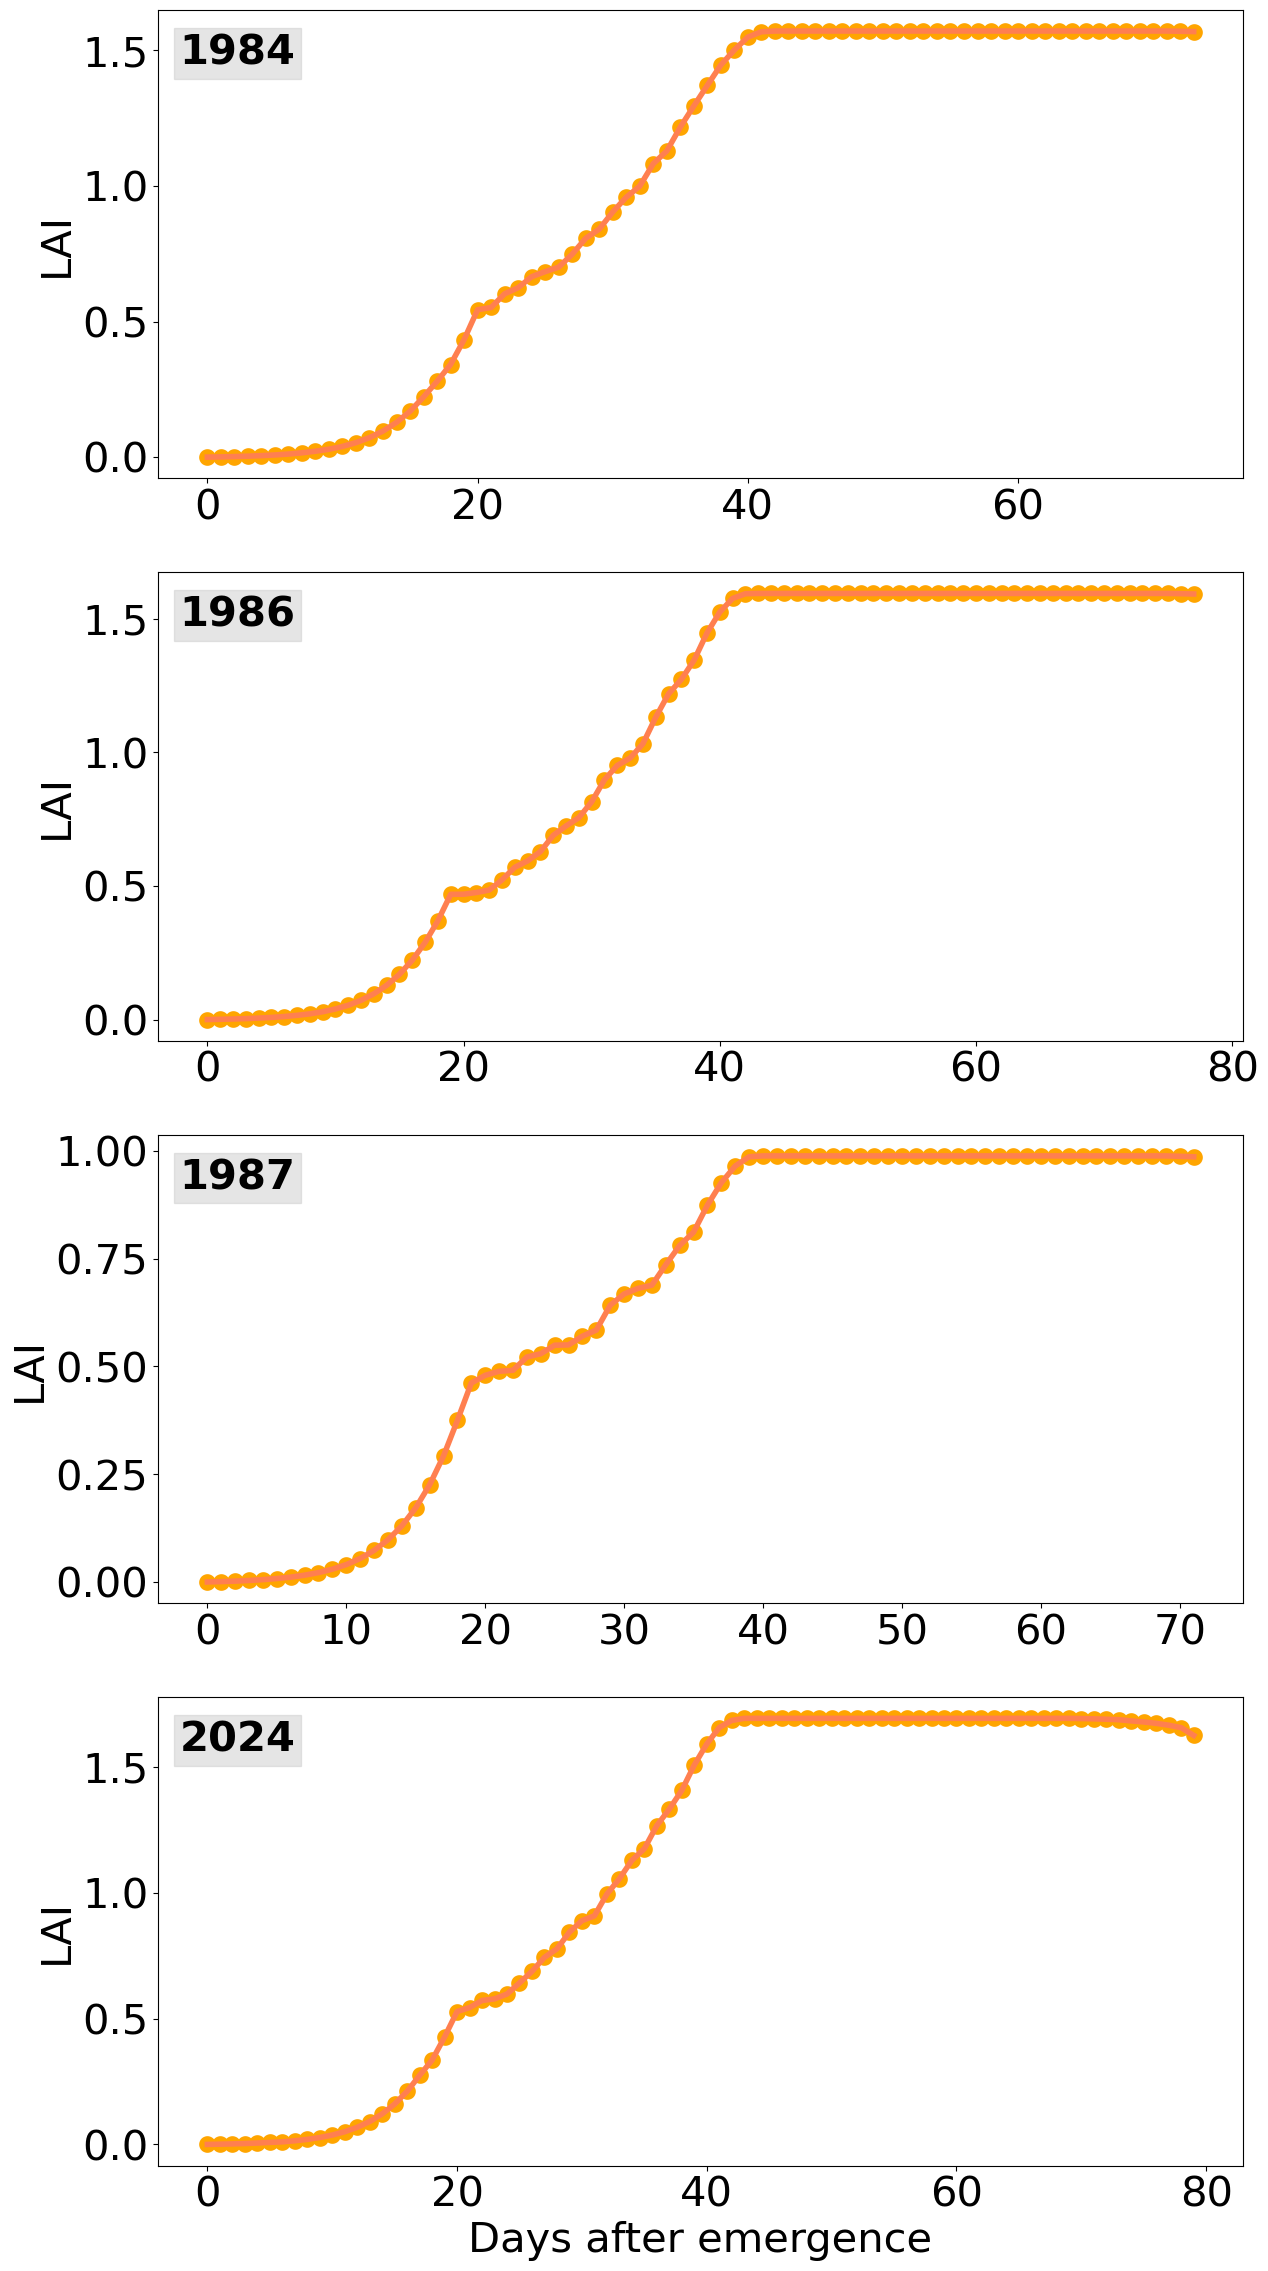

In [ ]:
phi_bounds = [30,80]
rmax_bounds = [0.5,1.0]
N_bounds = [10,40]

dic_3d = {}

tec_file='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plant_file='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'

fig, ax = plt.subplots(4,1, figsize=(14, 7*4))

for i,year in enumerate([1984,1986,1987,2024]):
    stics_output_file=f'../data/usms_STICS/v10/mod_ssorghum_ntarla_{year}.sti'

    density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
    dae = range(len(thermal_time))

    d, N, phi, rmax = compute_viable_parameter_space(N_bounds, phi_bounds, rmax_bounds, thermal_time, leaf_area_plant, index_end_veg, archi, end_veg_corr=5)
    
    pot_factor = 40
    growing_plant = compute_1_growing_plant(archi, d, daily_dynamics, leaf_area_plant, height_canopy, pot_factor=40)

    dic_3d[year] = growing_plant

    realized_la = np.array([sum(la - sen 
                            for la, sen in zip(gp.properties()["visible_leaf_area"].values(), gp.properties()["senescent_area"].values())) 
                            for gp in growing_plant.values()])

    # plt.plot(thermal_time[:index_end_veg+2], leaf_area_plant[:index_end_veg+2], color="black")
    ax[i].scatter(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=6, label='STICS stressed')
    ax[i].plot(dae, realized_la*density/10000, color="coral", linewidth=4, label='ArchiCrop stressed')
    ax[i].set_ylabel("LAI", fontsize=30)
    ax[i].tick_params(labelsize=30)
    ax[i].text(0.02, 0.95, f"{year}", transform=ax[i].transAxes, fontsize=30, verticalalignment='top', backgroundcolor=(0.8, 0.8, 0.8, 0.5), weight='bold') 
    
ax[i].set_xlabel("Days after emergence", fontsize=30)
plt.savefig(f"../figures/sorghum_sup_LAI_STICS_and_3D.png", dpi=1000)
plt.show()
    

In [ ]:
from openalea.archicrop.display import build_scene
from openalea.plantgl.all import Color3, Material, Viewer
from openalea.widgets.plantgl import *
%gui qt
m = Material(Color3(0,80,0))

times = [10,16,26,38,55,74]
mean_time = sum(times) / len(times)
positions = [(7*(t-mean_time), 0, 0) for t in times]
mtgs_list = [g for i,g in dic_3d[1984].items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)

In [48]:
mtgs_list = [g for i,g in dic_3d[1986].items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)

In [50]:
times = [10,16,26,38,55,69]
mean_time = sum(times) / len(times)
positions = [(7*(t-mean_time), 0, 0) for t in times]
mtgs_list = [g for i,g in dic_3d[1987].items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)

In [51]:
times = [10,16,26,38,55,74]
mean_time = sum(times) / len(times)
positions = [(7*(t-mean_time), 0, 0) for t in times]
mtgs_list = [g for i,g in dic_3d[2024].items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)